<a href="https://colab.research.google.com/github/KHOORUIXIANG/AmplifAI-Bootcamp-Basics-of-Neutral-Networks/blob/CNN/CNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="W8AO6CHx2jaE4XIKg3Jr")
project = rf.workspace("sushicnn-mvtiv").project("nasi-lemak-vs-sushi-uucxy")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...


In [3]:
!pip install torch

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Determine the device to use
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda:0


In [6]:
# Define transformations
# Common standard mean and standard deviation for image normalization
# Resizing to 64x64 is a good size for a simple model
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    # Normalize the tensor images
    transforms.Normalize(mean=MEAN, std=STD)
])

DATA_ROOT = '/content/Nasi-Lemak-vs-Sushi-1'

# 1. Create Image Datasets
try:
    # torchvision.datasets.ImageFolder automatically assigns labels based on folder names
    train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, '/content/Nasi-Lemak-vs-Sushi-1/train'), transform=transform)
    test_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, '/content/Nasi-Lemak-vs-Sushi-1/test'), transform=transform)

    # Print class mapping (0=elephant, 1=giraffe, assuming lexicographical order)
    print("Class mapping:", train_dataset.class_to_idx)

    # 2. Create Data Loaders
    BATCH_SIZE = 32
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Loaded {len(train_dataset)} training images and {len(test_dataset)} testing images.")

except:
    print(f"Failed to Load Data!")



Class mapping: {'Nasi Lemak': 0, 'Sushi': 1}
Loaded 195 training images and 9 testing images.


In [7]:
## 3. Define the Convolutional Neural Network (CNN)

#This architecture consists of two convolutional layers followed by max-pooling, and then two fully-connected layers to produce a binary classification output (2 classes).

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()

             # --- Feature Extractor Block (Convolutional Layers) ---
        # We use nn.Sequential to chain operations for clean construction.
        # output channel at previous block = input channel at next block
        self.features = nn.Sequential(
            # Block 1 (Input: 3x64x64)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), # Retain size
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32x32x32

            # Block 2 (Input: 32x32x32)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 64x16x16

            # Block 3 (Input: 64x16x16) - Added this block for more complexity
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 128x8x8
        )

        # Calculate the size of the feature map after three pooling operations
        FINAL_FLAT_SIZE = 128 * 8 * 8 # 8192

        # --- Classifier Block (Fully Connected Layers) ---
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), # Added Dropout to prevent overfitting
            nn.Linear(FINAL_FLAT_SIZE, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes) # Final output layer for 2 classes
        )

    def forward(self, x):
        # 1. Pass through the feature extractor
        x = self.features(x)
        # 2. Flatten for the classifier (starting from dimension 1, preserving batch dimension)
        x = torch.flatten(x, 1)
        # 3. Pass through the classifier
        x = self.classifier(x)
        return x



In [8]:
## 4. Loss Function and Optimizer
# Instantiate the model and move it to the device (CPU/GPU)
model = SimpleCNN(num_classes=2).to(device)
print(model)

#We use CrossEntropyLoss, which is standard for multi-class classification and combines `LogSoftmax` and `NLLLoss` for better numerical stability.
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=8192, out_features=512, bias=True

In [9]:
## 5. Training Function

#This function iterates through the dataset for a specified number of epochs.

def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train() # Set the model to training mode

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (inputs, labels) in enumerate(train_loader):
            # Move data to the selected device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%')

    print('Finished Training.')
    return model


NUM_EPOCHS = 60
# Start training
trained_model = train_model(model, train_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)


Epoch 1/60 | Loss: 3.3211 | Accuracy: 54.87%
Epoch 2/60 | Loss: 1.1816 | Accuracy: 74.36%
Epoch 3/60 | Loss: 0.6765 | Accuracy: 82.56%
Epoch 4/60 | Loss: 0.4146 | Accuracy: 83.08%
Epoch 5/60 | Loss: 0.2767 | Accuracy: 91.28%
Epoch 6/60 | Loss: 0.2500 | Accuracy: 91.28%
Epoch 7/60 | Loss: 0.1104 | Accuracy: 95.90%
Epoch 8/60 | Loss: 0.0773 | Accuracy: 97.44%
Epoch 9/60 | Loss: 0.0778 | Accuracy: 96.92%
Epoch 10/60 | Loss: 0.0791 | Accuracy: 97.95%
Epoch 11/60 | Loss: 0.0767 | Accuracy: 96.41%
Epoch 12/60 | Loss: 0.0492 | Accuracy: 97.95%
Epoch 13/60 | Loss: 0.0630 | Accuracy: 98.97%
Epoch 14/60 | Loss: 0.0268 | Accuracy: 99.49%
Epoch 15/60 | Loss: 0.0142 | Accuracy: 100.00%
Epoch 16/60 | Loss: 0.0143 | Accuracy: 99.49%
Epoch 17/60 | Loss: 0.0247 | Accuracy: 99.49%
Epoch 18/60 | Loss: 0.0380 | Accuracy: 98.46%
Epoch 19/60 | Loss: 0.0178 | Accuracy: 99.49%
Epoch 20/60 | Loss: 0.0373 | Accuracy: 98.46%
Epoch 21/60 | Loss: 0.0643 | Accuracy: 99.49%
Epoch 22/60 | Loss: 0.0768 | Accuracy: 95.

In [10]:
def test_model(model, test_loader):
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad(): # Disable gradient calculation for inference
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Get the predicted class (index of the max log-probability)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'\nModel Accuracy on Test Set: {accuracy:.2f}% ({correct}/{total})')

# Test the final model
test_model(trained_model, test_loader)



Model Accuracy on Test Set: 88.89% (8/9)


--------------------------------------------------
Selected Image Index: 4
True Label: NASI LEMAK
Predicted Label: NASI LEMAK
--------------------------------------------------


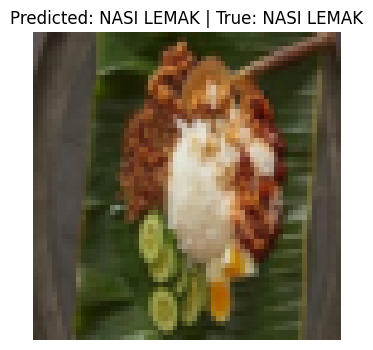

In [34]:
def unnormalize_tensor(tensor, mean, std):
    """Reverses the normalization for plotting."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor


def predict_example_image(model, dataset):

    model.eval()
    # 1. Select a random image index
    random_index = random.randint(0, len(dataset) - 1)

    # 2. Get the image tensor and true label
    image_tensor, true_label = dataset[random_index]

    # 3. Prepare image for model (add batch dimension and move to device)
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # 4. Run inference
    with torch.no_grad():
        output = model(input_tensor)
        # Get the predicted class index
        _, predicted_index = torch.max(output, 1)

    # 5. Get the class names
    classes = dataset.classes
    true_class = classes[true_label]
    predicted_class = classes[predicted_index.item()]

    # 6. Display the result
    print("-" * 50)
    print(f"Selected Image Index: {random_index}")
    print(f"True Label: {true_class.upper()}")
    print(f"Predicted Label: {predicted_class.upper()}")
    print("-" * 50)

    # 7. Plot the image
    # Clone and unnormalize the tensor for visualization
    img_for_plot = image_tensor.clone().cpu()
    unnormalize_tensor(img_for_plot, MEAN, STD)

    # PyTorch tensors are (C, H, W), Matplotlib needs (H, W, C)
    npimg = img_for_plot.numpy()
    plt.figure(figsize=(4, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Predicted: {predicted_class.upper()} | True: {true_class.upper()}")
    plt.axis('off')
    plt.show()

# Run the prediction on a random sample from the test set
predict_example_image(trained_model, test_dataset)